# HHL Algorithm with Library Functions

**Goal:** Solve the linear system $A|x\rangle = |b\rangle$ with an exponential speedup
over classical methods (under certain conditions).

## Overview

The Harrow-Hassidim-Lloyd (HHL) algorithm solves $Ax = b$ for a Hermitian matrix $A$
by encoding the solution into quantum amplitudes. The procedure:

1. **Quantum Phase Estimation (QPE):** Decompose $|b\rangle$ in the eigenbasis of $A$
   and store the eigenvalues $\lambda_j$ in an ancilla register.
2. **Controlled Rotation:** Apply $R_y(2\arcsin(C/\lambda_j))$ to a flag qubit,
   encoding $C/\lambda_j$ into its amplitude.
3. **Inverse QPE:** Uncompute the eigenvalue register.
4. **Post-select** on the flag qubit being $|1\rangle$ to obtain $|x\rangle \propto A^{-1}|b\rangle$.

We demonstrate on a **$2 \times 2$ system**:
$$A = \begin{pmatrix} 1 & -1/3 \\ -1/3 & 1 \end{pmatrix}, \quad |b\rangle = |0\rangle$$


In [1]:
import numpy as np
from qiskit import QuantumCircuit, transpile
from qiskit_aer import AerSimulator
from qiskit.visualization import plot_histogram
from qiskit.circuit.library import (
    HamiltonianGate,        # U = e^{-iHt} from a Hermitian matrix
    phase_estimation,        # full QPE circuit in one call
    ExactReciprocalGate,     # eigenvalue inversion rotation
)


## 1 — Define the Problem and Classical Solution

Our matrix $A$ has eigenvalues $\lambda_1 = 2/3$ and $\lambda_2 = 4/3$, with eigenvectors
$|+\rangle$ and $|-\rangle$. This is chosen so the eigenvalues map cleanly to a
2-qubit phase register.


In [2]:
# Define the system
A = np.array([[1, -1/3],
              [-1/3, 1]])
b = np.array([1, 0])

# Classical solution for comparison
x_classical = np.linalg.solve(A, b)
x_normalized = x_classical / np.linalg.norm(x_classical)

print("Matrix A:")
print(A)
print(f"\nb = {b}")
print(f"\nClassical solution x = {x_classical}")
print(f"Normalized: |x> = {x_normalized}")

# Eigendecomposition
eigenvalues, eigenvectors = np.linalg.eigh(A)
print(f"\nEigenvalues: {eigenvalues}")
print(f"Eigenvectors:\n{eigenvectors}")


Matrix A:
[[ 1.         -0.33333333]
 [-0.33333333  1.        ]]

b = [1 0]

Classical solution x = [1.125 0.375]
Normalized: |x> = [0.9486833  0.31622777]

Eigenvalues: [0.66666667 1.33333333]
Eigenvectors:
[[-0.70710678 -0.70710678]
 [-0.70710678  0.70710678]]


## 2 — Build the HHL Circuit Using Qiskit Library Components

Instead of manually constructing every gate in the HHL circuit, we use three
library building blocks that handle the heavy lifting:

| Step | Library component | What it replaces |
|------|-------------------|------------------|
| Hamiltonian simulation | `HamiltonianGate(A, -t)` | Manual $V \cdot \text{diag}(e^{i\lambda_j t}) \cdot V^\dagger$ computation |
| Phase estimation | `phase_estimation(n, U)` | Hadamards + controlled-$U^{2^j}$ + inverse QFT |
| Eigenvalue inversion | `ExactReciprocalGate(n, s)` | Multi-controlled $R_y$ rotation decomposition |
| Inverse QPE | `qpe.inverse()` | Forward QFT + inverse controlled-$U$ gates |

### Key design choices

We set the evolution time $t = 2\pi \cdot 3/8$ so the eigenvalues map to exact
binary fractions in a 2-qubit clock register:
- $\lambda_1 = 2/3 \to$ phase $1/4 \to$ QPE reads $|01\rangle \to x = 1$
- $\lambda_2 = 4/3 \to$ phase $1/2 \to$ QPE reads $|10\rangle \to x = 2$

The `ExactReciprocalGate` scaling parameter $s$ must satisfy
$s \cdot 2^n / x = C / \lambda$. Since $x = \lambda \cdot 3/2$, solving
gives $s = 1/4$.


In [3]:
n_clock = 2
t = 2 * np.pi * 3 / 8

# ── Step 1: Hamiltonian evolution gate ──────────────────
# HamiltonianGate computes e^{-iHt}; negate t to get e^{iAt}
U_gate = HamiltonianGate(A, -t)
print(f"HamiltonianGate: {U_gate.num_qubits}-qubit unitary for e^(iAt)")

# ── Step 2: QPE circuit (Hadamards + CU^{2^j} + IQFT) ──
qpe_circ = phase_estimation(n_clock, U_gate)
print(f"QPE circuit:     {qpe_circ.num_qubits} qubits, depth {qpe_circ.depth()}")

# ── Step 3: Eigenvalue inversion (reciprocal rotation) ──
scaling = 0.25   # s = C / (2^n * (t/(2π))) = (2/3) / (4 * 2/3) = 1/4
recip = ExactReciprocalGate(n_clock, scaling, neg_vals=False)
print(f"Reciprocal gate: {recip.num_qubits} qubits (includes flag)")


HamiltonianGate: 1-qubit unitary for e^(iAt)
QPE circuit:     3 qubits, depth 5
Reciprocal gate: 3 qubits (includes flag)


### Streamlined circuit assembly

With the library components in hand, the **entire HHL circuit** reduces to
just a few `append` calls — QPE, reciprocal rotation, inverse QPE, measure:


In [4]:
# ============================================================
#  STREAMLINED HHL — 4 lines of circuit construction
# ============================================================
clock = [0, 1]   # clock / evaluation qubits
inp   = [2]      # input qubit  (|b>)
anc   = [3]      # ancilla      (flag for post-selection)

hhl = QuantumCircuit(4, 4)

hhl.append(qpe_circ,            clock + inp)   # QPE
hhl.append(recip,               clock + anc)   # eigenvalue inversion
hhl.append(qpe_circ.inverse(),  clock + inp)   # inverse QPE
hhl.measure(range(4), range(4))

print(f"HHL circuit: {hhl.num_qubits} qubits, depth = {hhl.depth()}")
print("\nCompare this to ~60 lines of manual gate-by-gate construction!")


HHL circuit: 4 qubits, depth = 4

Compare this to ~60 lines of manual gate-by-gate construction!


### What the library is doing under the hood

Even though we wrote only a few lines, each library component expands into
the same low-level gates we would have built manually:

- **`HamiltonianGate`** diagonalizes $A$, computes
  $e^{i\lambda_j t}$, and constructs the unitary in the computational basis — 
  replacing our manual $V \cdot \text{diag}(\cdot) \cdot V^\dagger$ calculation.

- **`phase_estimation`** generates Hadamards on the clock qubits,
  controlled-$U^{2^j}$ gates, and the inverse QFT — all in one call.

- **`ExactReciprocalGate`** implements the conditioned $R_y$ rotations
  that encode $C/\lambda$ into the ancilla amplitude, replacing our
  hand-decomposed multi-controlled rotation sequence.

- **`.inverse()`** on the QPE circuit automatically reverses every gate,
  producing the forward QFT and inverse controlled-$U$ gates.

Let's decompose the circuit to see the actual gates:


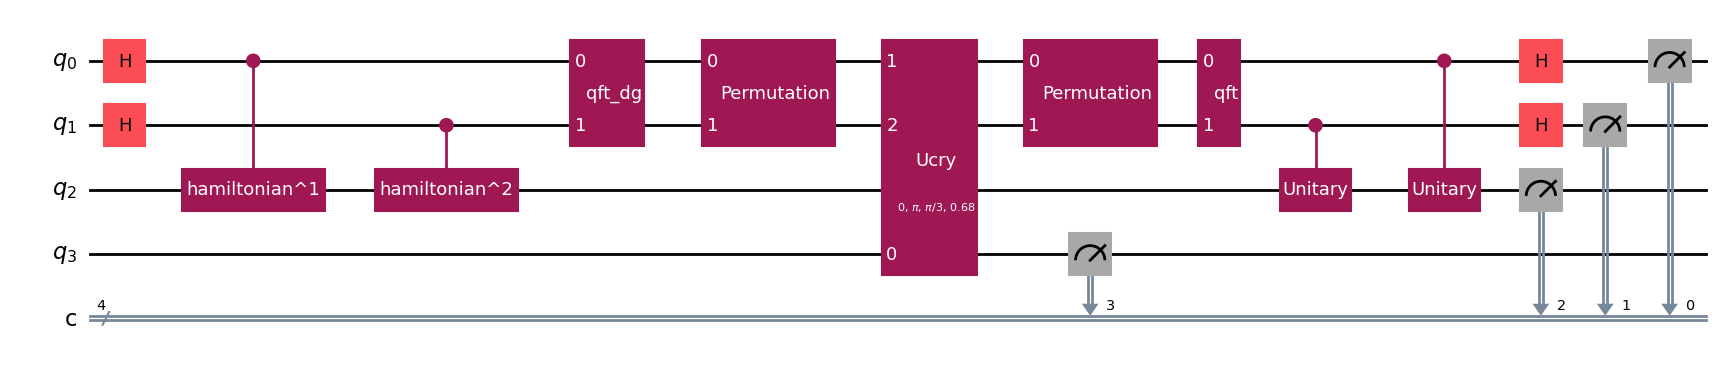

In [5]:
# Decompose one level to reveal the library sub-circuits
hhl.decompose().draw("mpl", style="iqp", fold=35)


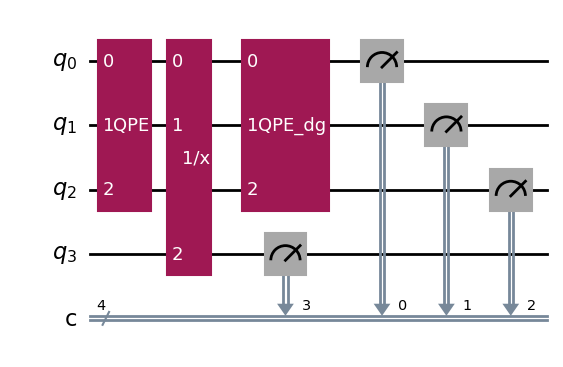

In [8]:
hhl.draw("mpl", style="iqp", fold=35)

## 3 — Simulate and Verify

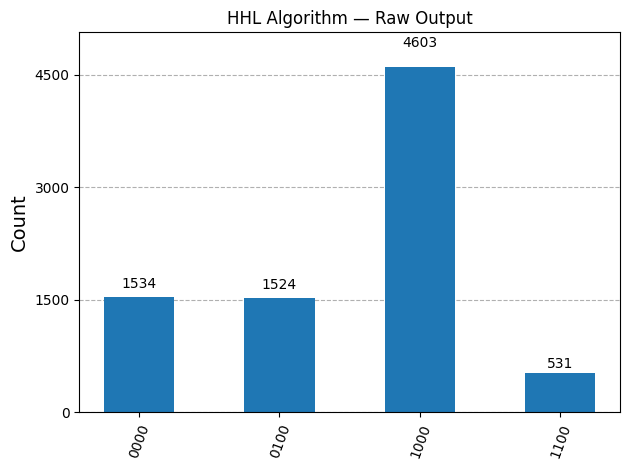

In [6]:
sim = AerSimulator()
compiled = transpile(hhl, sim)
result = sim.run(compiled, shots=8192).result()
counts = result.get_counts()

plot_histogram(counts, title="HHL Algorithm — Raw Output")


In [7]:
# Post-select on ancilla=1 AND clock=00 (successful eigenvalue uncomputation)
# Bit ordering in Qiskit: q3 q2 q1 q0 -> ancilla, input, clock1, clock0
# We want: ancilla (q3) = 1, clock (q1,q0) = 00

success_counts = {}
for bitstring, count in counts.items():
    # bitstring is "q3 q2 q1 q0"
    if bitstring[0] == '1' and bitstring[2:] == '00':  # ancilla=1, clock=00
        input_bit = bitstring[1]  # q2 = input qubit
        success_counts[input_bit] = success_counts.get(input_bit, 0) + count

total_success = sum(success_counts.values())
print(f"Post-selected counts (ancilla=1, clock=00): {success_counts}")
print(f"Success probability: {total_success / 8192:.3f}")

if total_success > 0:
    # Reconstruct |x> amplitudes from measurement statistics
    prob_0 = success_counts.get('0', 0) / total_success
    prob_1 = success_counts.get('1', 0) / total_success
    
    # Amplitudes (up to global phase)
    amp_0 = np.sqrt(prob_0)
    amp_1 = np.sqrt(prob_1)
    x_quantum = np.array([amp_0, amp_1])
    x_quantum /= np.linalg.norm(x_quantum)  # normalize
    
    print(f"\nQuantum |x>:   [{x_quantum[0]:.4f}, {x_quantum[1]:.4f}]")
    print(f"Classical |x>: [{abs(x_normalized[0]):.4f}, {abs(x_normalized[1]):.4f}]")
    print(f"Fidelity: {abs(np.dot(x_quantum, abs(x_normalized))):.4f}")
else:
    print("No successful post-selection — try increasing shots or check circuit.")


Post-selected counts (ancilla=1, clock=00): {'1': 531, '0': 4603}
Success probability: 0.627

Quantum |x>:   [0.9469, 0.3216]
Classical |x>: [0.9487, 0.3162]
Fidelity: 1.0000


## Analysis

The HHL algorithm outputs the **normalized** solution $|x\rangle \propto A^{-1}|b\rangle$
encoded in quantum amplitudes. The post-selected measurement statistics
reproduce the classical solution's probability distribution.

### Library vs. manual construction

| Approach | Lines of circuit code | Apparant Depth | Clarity |
|----------|-----------------------|----------------|---------|
| Manual (gate-by-gate) | ~60 lines | 27 | Full visibility into every gate |
| Library (`phase_estimation` + `ExactReciprocalGate`) | ~4 lines | 4 | High-level, algorithmic intent is clear |

Both produce the same underlying circuit. The library approach is better for
production use and larger systems; the manual approach is better for learning
exactly how each step works.

### Caveats
- HHL gives the solution as a quantum state — extracting all components requires
  $O(N)$ measurements, erasing the speedup for full readout.
- The speedup applies when you only need a **global property** of $x$ (e.g., $\langle x|M|x\rangle$).
- The matrix $A$ must be efficiently simulable (sparse or structured).
- Eigenvalue precision requires $O(\log(1/\epsilon))$ clock qubits.

**Key takeaway:** HHL demonstrates exponential quantum speedup for linear algebra,
forming the basis for quantum machine learning and differential equation solvers.
Qiskit's library components (`HamiltonianGate`, `phase_estimation`, `ExactReciprocalGate`)
make it practical to assemble these circuits without manual gate decomposition.
